In [1]:
import xarray as xr

import time

Timers: Open = 2.161457584006712, Load = 2.3999993572942913e-05, Mean = 0.2722807499958435, Plot = 0.027101041006972082 ... TOTAL: 2.4608633750031004 seconds
CPU times: user 1.54 s, sys: 396 ms, total: 1.94 s
Wall time: 2.46 s


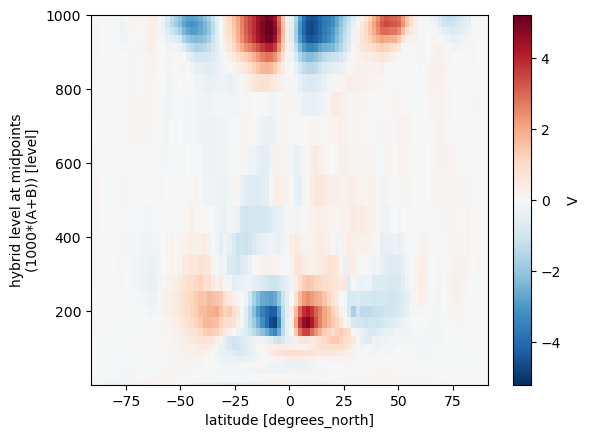

In [2]:
%%time

t0 = time.perf_counter()
ds_orig = xr.open_dataset("/Users/brianpm/Desktop/orig.nc")
t1 = time.perf_counter()
x_orig = ds_orig['V']
t2 = time.perf_counter()
v_orig_mean = x_orig.mean(dim=("time","lon"))
t3 = time.perf_counter()
v_orig_mean.plot.pcolormesh()
t4 = time.perf_counter()
print(f"Timers: Open = {t1-t0}, Load = {t2-t1}, Mean = {t3-t2}, Plot = {t4 - t3} ... TOTAL: {t4-t0} seconds")


Timers: Open = 0.24669366699527018, Load = 1.9167011487297714e-05, Mean = 1.6298639999877196, Plot = 0.008699000012711622 ... TOTAL: 1.8852758340071887 seconds
CPU times: user 1.59 s, sys: 271 ms, total: 1.86 s
Wall time: 1.89 s


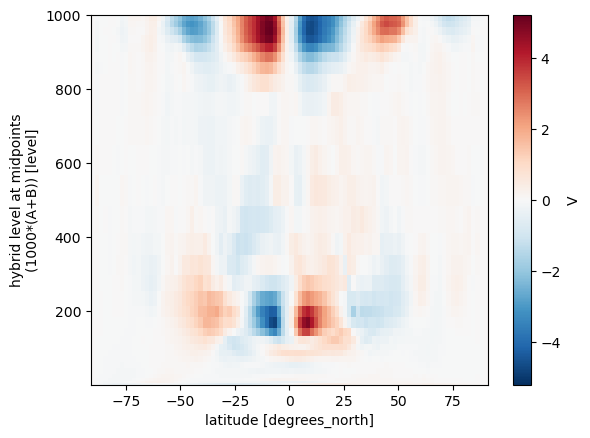

In [3]:
%%time
t0 = time.perf_counter()
ds_comp = xr.open_dataset("/Users/brianpm/Desktop/compressed.nc")
t1 = time.perf_counter()
x_comp = ds_comp['V']
t2 = time.perf_counter()
v_comp_mean = x_comp.mean(dim=("time","lon"))
t3 = time.perf_counter()
v_comp_mean.plot.pcolormesh()
t4 = time.perf_counter()
print(f"Timers: Open = {t1-t0}, Load = {t2-t1}, Mean = {t3-t2}, Plot = {t4 - t3} ... TOTAL: {t4-t0} seconds")



Timers: Open = 0.027171291003469378, Load = 2.4916997062973678e-05, Mean = 1.8612290419987403, Plot = 0.1034430409927154 ... TOTAL: 1.991868290991988 seconds
CPU times: user 1.66 s, sys: 318 ms, total: 1.98 s
Wall time: 1.99 s


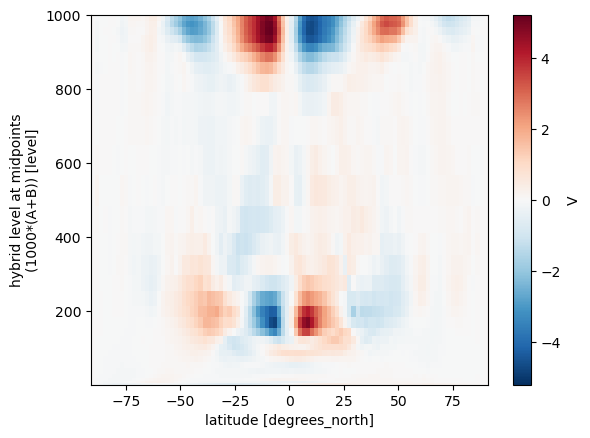

In [12]:
%%time
t0 = time.perf_counter()
ds_comp_a = xr.open_dataset("/Users/brianpm/Desktop/compress_z1.nc")
t1 = time.perf_counter()
x_comp_a = ds_comp_a['V']
t2 = time.perf_counter()
v_comp_a_mean = x_comp_a.mean(dim=("time","lon"))
t3 = time.perf_counter()
v_comp_a_mean.plot.pcolormesh()
t4 = time.perf_counter()
print(f"Timers: Open = {t1-t0}, Load = {t2-t1}, Mean = {t3-t2}, Plot = {t4 - t3} ... TOTAL: {t4-t0} seconds")



Timers: Open = 0.027904041999136098, Load = 2.666599175427109e-05, Mean = 1.866766709004878, Plot = 0.008669832997838967 ... TOTAL: 1.9033672499936074 seconds
CPU times: user 1.61 s, sys: 265 ms, total: 1.87 s
Wall time: 1.9 s


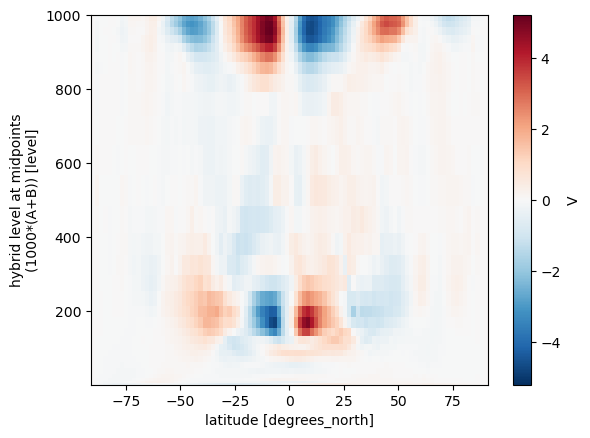

In [14]:
%%time
t0 = time.perf_counter()
ds_comp_5 = xr.open_dataset("/Users/brianpm/Desktop/compress_z5.nc")
t1 = time.perf_counter()
x_comp_5 = ds_comp_5['V']
t2 = time.perf_counter()
v_comp_5_mean = x_comp_5.mean(dim=("time","lon"))
t3 = time.perf_counter()
v_comp_5_mean.plot.pcolormesh()
t4 = time.perf_counter()
print(f"Timers: Open = {t1-t0}, Load = {t2-t1}, Mean = {t3-t2}, Plot = {t4 - t3} ... TOTAL: {t4-t0} seconds")



Timers: Open = 0.02107895800145343, Load = 1.779200101736933e-05, Mean = 1.9697340410057222, Plot = 0.008436666990746744 ... TOTAL: 1.9992674579989398 seconds
CPU times: user 1.73 s, sys: 269 ms, total: 2 s
Wall time: 2 s


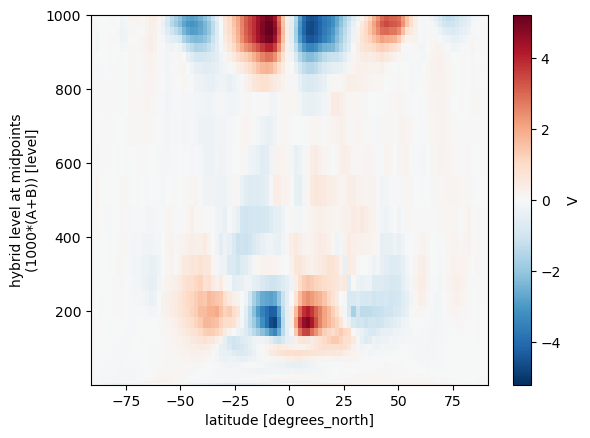

In [16]:
%%time
t0 = time.perf_counter()
ds_comp_b = xr.open_dataset("/Users/brianpm/Desktop/compress_dfl4z5.nc")
t1 = time.perf_counter()
x_comp_b = ds_comp_b['V']
t2 = time.perf_counter()
v_comp_b_mean = x_comp_b.mean(dim=("time","lon"))
t3 = time.perf_counter()
v_comp_b_mean.plot.pcolormesh()
t4 = time.perf_counter()
print(f"Timers: Open = {t1-t0}, Load = {t2-t1}, Mean = {t3-t2}, Plot = {t4 - t3} ... TOTAL: {t4-t0} seconds")



In [17]:
import numpy as np
for dv in ds_comp_b.data_vars:
    if dv in ds_orig:
        try:
            difference = np.max(np.absolute(ds_orig[dv] - ds_comp_b[dv]))
            print(f"{dv}: {difference.item()}")
        except:
            print(f"{dv} - difference didn't work.")

P0: 0.0
V: 0.00390625
ch4vmr: 3.0360221862784553e-10
co2vmr: 2.808380126953329e-08
date: 0
date_written - difference didn't work.
datesec: 0
f11vmr: 0.0
f12vmr: 0.0
gw: 3.7441302271901122e-06
hyai: 3.6954224795666957e-06
hyam: 3.6233504453753174e-06
hybi: 3.0323349245464648e-05
hybm: 2.6825640385252925e-05
mdt: 0
n2ovmr: 2.3265779018538915e-12
nbdate: 0
nbsec: 0
ndbase: 0
ndcur: 0
nlon: 0
nsbase: 0
nscur: 0
nsteph: 0
ntrk: 0
ntrm: 0
ntrn: 0
sol_tsi: 0.0
time_bnds: 0
time_written - difference didn't work.
w_stag: 3.802021012244694e-06
wnummax: 0


In [11]:
import numpy as np
for dv in ds_comp.data_vars:
    if dv in ds_orig:
        try:
            difference = np.max(np.absolute(ds_orig[dv] - ds_comp[dv]))
            print(f"{dv}: {difference.item()}")
        except:
            print(f"{dv} - difference didn't work.")

P0: 32.0
V: 0.03125
ch4vmr: 3.4216880798340685e-09
co2vmr: 9.112548828124796e-08
date: 0
date_written - difference didn't work.
datesec: 0
f11vmr: 0.0
f12vmr: 0.0
gw: 2.9417608218285096e-05
hyai: 3.007426857949691e-05
hyam: 3.0050054192501396e-05
hybi: 0.0004670832826895177
hybm: 0.0004478604385407814
mdt: 0
n2ovmr: 4.0512704849241796e-10
nbdate: 0
nbsec: 0
ndbase: 0
ndcur: 0
nlon: 0
nsbase: 0
nscur: 0
nsteph: 0
ntrk: 0
ntrm: 0
ntrn: 0
sol_tsi: 0.0
time_bnds: 0
time_written - difference didn't work.
w_stag: 2.9790375613833464e-05
wnummax: 0
